In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import CMR_IA as cmr
import scipy as sp
import json

from CMR_IA.utils import wmse

cmr.analysis.setup_notebook()

SAVEFIG = False
SAVERES = False
SAVERES2 = True

## Load Stimuli and Semantic Matrix

In [2]:
# Load study and test data
df_study = pd.read_parquet("data/simu8_study.parquet")
df_test = pd.read_parquet("data/simu8_test.parquet")

In [3]:
# Inspect study data
df_study

,study_itemno1,study_itemno2,study_item1,study_item2,serial_pos,list,session,group
0,12,24,Face12,Joe,0,0,0,1
1,2,29,Face2,Mark,1,0,0,1
2,6,27,Face6,Dan,2,0,0,1
3,13,18,Face13,John,3,0,0,1
4,11,31,Face11,George,4,0,0,1
...,...,...,...,...,...,...,...,...
239995,12,18,Face12,John,11,0,9999,2
239996,7,29,Face7,Mark,12,0,9999,2
239997,10,26,Face10,Chris,13,0,9999,2
239998,1,23,Face1,Charles,14,0,9999,2


In [4]:
# Inspect test data
df_test

,test_itemno1,test_itemno2,test_item1,test_item2,correct_ans,study_pos,test,list,session,group
0,1,-1,Face1,None,30,6,1,0,0,1
1,2,-1,Face2,None,29,1,1,0,0,1
2,6,-1,Face6,None,27,2,1,0,0,1
3,14,-1,Face14,None,22,7,1,0,0,1
4,13,-1,Face13,None,18,3,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...
399995,12,-1,Face12,None,18,11,2,0,9999,2
399996,3,-1,Face3,None,25,15,2,0,9999,2
399997,10,-1,Face10,None,26,13,2,0,9999,2
399998,16,-1,Face16,None,19,0,2,0,9999,2


In [5]:
# Load semantic matrix
sem_mat = np.load("data/simu8_smat.npy")

In [6]:
# A check
S = np.load("data/simu8_smat.npy")
dist = np.load("data/simu8_distance.npy")
F = S[:16, :16].copy()
np.fill_diagonal(F, 0)
neigh = ((dist < 3.0) & (dist > 0)).sum(1)
nsv2 = (F**2).sum(1)
msim = F.sum(1) / 15
print(
    "face block off-diag sim: %.3f .. %.3f (mean %.3f)"
    % (F[F > 0].min(), F.max(), F[F > 0].mean())
)
print(
    "corr(neigh, ||svec||^2) = %+.3f   corr(neigh, meanSim) = %+.3f"
    % (np.corrcoef(neigh, nsv2)[0, 1], np.corrcoef(neigh, msim)[0, 1])
)
print(
    "S at d=[1.5,2.5,3.5,4.5]:",
    [round(1 / (1 + np.exp(1.5 * (d - 3))), 3) for d in (1.5, 2.5, 3.5, 4.5)],
)

face block off-diag sim: 0.168 .. 0.958 (mean 0.541)
corr(neigh, ||svec||^2) = +0.737   corr(neigh, meanSim) = +0.811
S at d=[1.5,2.5,3.5,4.5]: [0.905, 0.679, 0.321, 0.095]


# Group 2

In [7]:
df_study_g2 = df_study.query("group == 2").copy()
df_test_g2 = df_test.query("group == 2").copy()
# df_study_g2 = df_study_g2.query("session < 2000").copy()
# df_test_g2 = df_test_g2.query("session < 2000").copy()

## Run CMR-IA

In [8]:
# Define parameters and load PSO results
params = cmr.load_params("8", params_path="data/g2_260625_200-100.json", fixed_params={"learn_while_retrieving": True, "nitems_in_accumulator": 32, "ban_recall": np.arange(1, 17)})
params.update(beta_rec=0.9, kappa=0.5, lamb=0.2, eta=0.2, omega=10, alpha=1, c_thresh=1, rec_time_limit=1000.)  #
params

{'beta_enc': 0.695993,
 'beta_rec': 0.9,
 'beta_cue': 0.70243,
 'beta_rec_post': 0.742474,
 'beta_distract': 0.611613,
 'beta_enc_inpair': None,
 's_fc': 0.502042,
 's_cf': 0.0,
 'phi_s': 0.0,
 'phi_d': 0.0,
 'psi_s': 0.0,
 'psi_c': 1.0,
 'd_assoc': None,
 'use_new_context': True,
 'use_flexible_thresh': True,
 'c_d': 2.429634,
 'thresh_kernel_len': 10,
 'c_thresh_itm': 1.0,
 'c_thresh_assoc': 0.983939,
 'c_s': 0.0,
 'thresh_sigma': 0.0,
 'recog_slope': 1.0,
 'kappa': 0.5,
 'eta': 0.2,
 'omega': 10,
 'alpha': 1,
 'lamb': 0.2,
 'c_thresh': 1,
 'ban_recall': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16]),
 'rec_time_limit': 1000.0,
 'dt': 10,
 'nitems_in_accumulator': 32,
 'max_recalls': 50,
 'learn_while_retrieving': True,
 'gamma_fc': 0.243692,
 'gamma_cf': 0.0}

In [9]:
# Run model or load saved results
if SAVERES2:
    df_simu_g2, f_in, f_dif = cmr.run_success_multi_sess(params, df_study_g2, df_test_g2, sem_mat, mode="Recog-CR", design="S1G3")
    df_simu_g2["test"] = df_test_g2["test"]
    df_simu_g2 = df_simu_g2.merge(df_test_g2, on=["session", "list", "test", "test_itemno1", "test_itemno2"])
#     df_simu_g2.to_parquet("data/simu8_result_g2.parquet")
# else:
#     df_simu_g2 = pd.read_parquet("data/simu8_result_g2.parquet")
df_simu_g2

  0%|          | 28/10000 [00:00<02:24, 69.00it/s]

100%|██████████| 10000/10000 [02:26<00:00, 68.34it/s]


CMR Time: 146.48622155189514


,session,list,test_itemno1,test_itemno2,s_resp,s_rt,csim,thresh,test,test_item1,test_item2,correct_ans,study_pos,group
0,0,0,15,30,0,0,0.290442,0.353786,1,Face15,Mike,1,-1,2
1,0,0,4,17,0,0,0.278290,0.291766,1,Face4,Jim,1,-1,2
2,0,0,10,28,0,0,0.209678,0.275401,1,Face10,Paul,0,-1,2
3,0,0,2,23,1,0,0.289338,0.212395,1,Face2,Charles,1,-1,2
4,0,0,1,27,0,0,0.208311,0.278324,1,Face1,Dan,0,-1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319995,9999,0,12,-1,-1,-1,-1.000000,-1.000000,2,Face12,None,18,11,2
319996,9999,0,3,-1,-1,-1,-1.000000,-1.000000,2,Face3,None,25,15,2
319997,9999,0,10,-1,-1,-1,-1.000000,-1.000000,2,Face10,None,26,13,2
319998,9999,0,16,-1,-1,-1,-1.000000,-1.000000,2,Face16,None,19,0,2


## Analysis

In [10]:
# Split recognition and cued recall responses
df_recog = df_simu_g2.query("test == 1").copy()
df_cr = df_simu_g2.query("test == 2").copy()

In [11]:
# Get name-face pair dict for each session
sess_name_face = {}
for sess in df_study_g2.session.unique():
    sess_name_face[sess] = df_study_g2.query(f"session == {sess}")[["study_itemno1", "study_itemno2"]].set_index("study_itemno2").to_dict()["study_itemno1"]

### Neighborhood Effect

In [12]:
# Load face distance matrix and compute neighbour counts (all 16 faces studied every session)
face_distance = np.load("data/simu8_distance.npy")
thresh = 3.0
neighbour_count = ((face_distance < thresh) & (face_distance > 0)).sum(axis=1)

# Density group of each recognition probe face
df_recog["neighbour"] = df_recog["test_itemno1"].apply(lambda f: neighbour_count[f - 1])
df_recog["density"] = pd.cut(df_recog["neighbour"], [4, 6, 8, 10], labels=["low", "medium", "high"])
df_recog["yes"] = (df_recog["s_resp"] == 1).astype(int)
df_recog

,session,list,test_itemno1,test_itemno2,s_resp,s_rt,csim,thresh,test,test_item1,test_item2,correct_ans,study_pos,group,neighbour,density,yes
0,0,0,15,30,0,0,0.290442,0.353786,1,Face15,Mike,1,-1,2,10,high,0
1,0,0,4,17,0,0,0.278290,0.291766,1,Face4,Jim,1,-1,2,6,low,0
2,0,0,10,28,0,0,0.209678,0.275401,1,Face10,Paul,0,-1,2,10,high,0
3,0,0,2,23,1,0,0.289338,0.212395,1,Face2,Charles,1,-1,2,8,medium,1
4,0,0,1,27,0,0,0.208311,0.278324,1,Face1,Dan,0,-1,2,10,high,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319979,9999,0,13,20,1,0,0.283181,0.272107,1,Face13,Bill,1,-1,2,8,medium,1
319980,9999,0,6,28,1,0,0.279988,0.278058,1,Face6,Paul,1,-1,2,7,medium,1
319981,9999,0,12,17,0,0,0.240637,0.275717,1,Face12,Jim,0,-1,2,8,medium,0
319982,9999,0,8,21,1,0,0.286030,0.240202,1,Face8,Dave,1,-1,2,5,low,1


In [13]:
# Hit rate and false alarm rate by density
df_hr = df_recog.query("correct_ans == 1").groupby("density", observed=True).yes.mean().reset_index(name="HR")
df_far = df_recog.query("correct_ans == 0").groupby("density", observed=True).yes.mean().reset_index(name="FAR")
df_hr, df_far

(  density        HR
 0     low  0.809078
 1  medium  0.805411
 2    high  0.800998,
   density       FAR
 0     low  0.281032
 1  medium  0.293172
 2    high  0.300785)

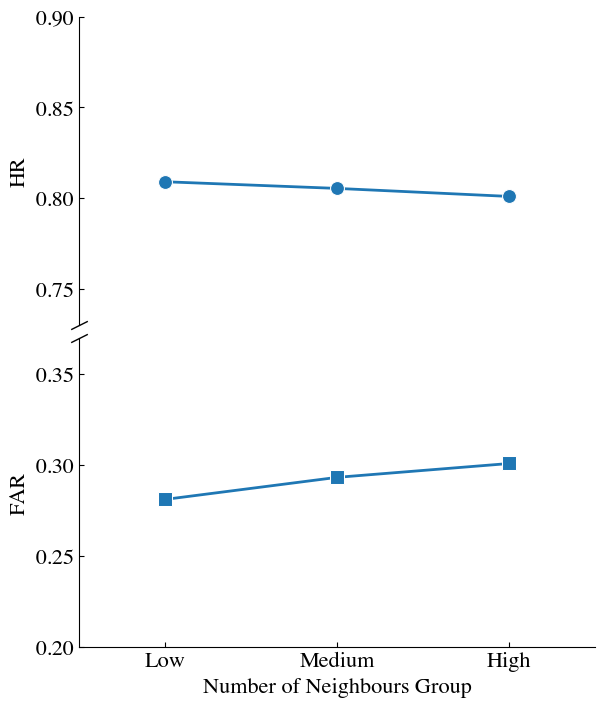

In [14]:
# Plot hit rate and false alarm rate by density (stacked, broken y-axis)
xpos = np.arange(3)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 7))
fig.subplots_adjust(left=0.12, right=0.98, bottom=0.08, top=0.98, hspace=0.04)

sns.lineplot(x=xpos, y=df_hr["HR"].to_numpy(), ax=ax1, marker="o", color="C0", markersize=10, linewidth=2)
sns.lineplot(x=xpos, y=df_far["FAR"].to_numpy(), ax=ax2, marker="s", color="C0", markersize=10, linewidth=2)

# ax1.set_ylim(0.73, 0.90)
# ax2.set_ylim(0.20, 0.37)
for ax in (ax1, ax2):
    ax.tick_params(axis="y", direction="in")
    ax.tick_params(axis="x", direction="in")
    ax.spines.right.set_visible(False)
ax1.spines.bottom.set_visible(False)
ax1.spines.top.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.tick_params(axis="x", which="both", bottom=False)

# Slanted break marks between the two panels
d = 0.5
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12, linestyle="none", color="k", mec="k", mew=1, clip_on=False)
ax1.plot(0, 0, transform=ax1.transAxes, **kwargs)
ax2.plot(0, 1, transform=ax2.transAxes, **kwargs)

ax1.set_ylim(0.73, 0.90)
ax2.set_ylim(0.20, 0.37)
ax2.set_xticks(xpos)
ax2.set_xticklabels(["Low", "Medium", "High"])
ax2.set_xlim(-0.5, 2.5)
ax1.set_ylabel("HR")
ax2.set_ylabel("FAR")
ax2.set_xlabel("Number of Neighbours Group")

if SAVEFIG:
    ax1.set_ylabel(None)
    ax2.set_ylabel(None)
    ax2.set_xlabel(None)
    plt.savefig("figures/simu8_g2_hrfar-neighbor.pdf")
plt.show()

### Probe Distance Effect

In [15]:
# Distance from each lure probe to the studied face of its (mismatched) name; targets sit at distance 0
def get_probe_distance(x):
    if x["correct_ans"] == 1:
        return 0.0
    resp_face = sess_name_face[x["session"]][x["test_itemno2"]]
    return face_distance[x["test_itemno1"] - 1, resp_face - 1]


lure_edges = [0.5, 1.5, 2.5, 3.5, 4.5]
lure_labels = ["1.5", "2.5", "3.5", "4.5"]
df_recog["probe_distance"] = df_recog.apply(get_probe_distance, axis=1)
df_recog["distance_bin"] = np.where(df_recog["correct_ans"] == 1, "Targets", pd.cut(df_recog["probe_distance"], lure_edges, labels=lure_labels).astype(object))
dbin_order = ["Targets"] + lure_labels
df_recog

,session,list,test_itemno1,test_itemno2,s_resp,s_rt,csim,thresh,test,test_item1,test_item2,correct_ans,study_pos,group,neighbour,density,yes,probe_distance,distance_bin
0,0,0,15,30,0,0,0.290442,0.353786,1,Face15,Mike,1,-1,2,10,high,0,0.0000,Targets
1,0,0,4,17,0,0,0.278290,0.291766,1,Face4,Jim,1,-1,2,6,low,0,0.0000,Targets
2,0,0,10,28,0,0,0.209678,0.275401,1,Face10,Paul,0,-1,2,10,high,0,2.2956,2.5
3,0,0,2,23,1,0,0.289338,0.212395,1,Face2,Charles,1,-1,2,8,medium,1,0.0000,Targets
4,0,0,1,27,0,0,0.208311,0.278324,1,Face1,Dan,0,-1,2,10,high,0,2.7583,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319979,9999,0,13,20,1,0,0.283181,0.272107,1,Face13,Bill,1,-1,2,8,medium,1,0.0000,Targets
319980,9999,0,6,28,1,0,0.279988,0.278058,1,Face6,Paul,1,-1,2,7,medium,1,0.0000,Targets
319981,9999,0,12,17,0,0,0.240637,0.275717,1,Face12,Jim,0,-1,2,8,medium,0,2.4857,2.5
319982,9999,0,8,21,1,0,0.286030,0.240202,1,Face8,Dave,1,-1,2,5,low,1,0.0000,Targets


In [16]:
# Yes rate by probe distance bin
df_yes_distance = df_recog.groupby("distance_bin").yes.mean().reindex(dbin_order).reset_index(name="yes_rate")
df_yes_distance

,distance_bin,yes_rate
0,Targets,0.804438
1,1.5,0.335888
2,2.5,0.293067
3,3.5,0.210142
4,4.5,0.131630


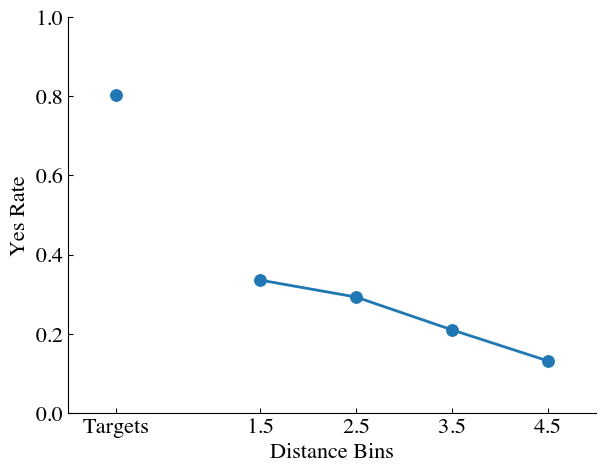

In [17]:
# Plot yes rate by probe distance
xpos = [0, 1.5, 2.5, 3.5, 4.5]
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
sns.lineplot(data=df_yes_distance, x=xpos, y="yes_rate", ax=ax, marker="o", color="C0", markersize=10, linewidth=0)
sns.lineplot(data=df_yes_distance.query("distance_bin != 'Targets'"), x=xpos[1:], y="yes_rate", ax=ax, marker=None, color="C0", markersize=10, linewidth=2, linestyle="-")
plt.xlim([-0.5, 5])
plt.ylim([0, 1])
plt.xticks(ticks=xpos, labels=df_yes_distance["distance_bin"])
plt.xlabel("Distance Bins")
plt.ylabel("Yes Rate")

if SAVEFIG:
    ax.set(xlabel=None, ylabel=None)
    plt.tick_params(labelleft=False)
    plt.savefig("figures/simu8_g2_yes-distance.pdf")
plt.show()

In [18]:
# Load ground truth
with open("data/simu8_gt.json") as f:
    gt = json.load(f)
hr_mean_gt = np.array(gt["exp3_neighbor_hr_mean"])
hr_se_gt = np.array(gt["exp3_neighbor_hr_se"])
far_mean_gt = np.array(gt["exp3_neighbor_far_mean"])
far_se_gt = np.array(gt["exp3_neighbor_far_se"])
yesdist_mean_gt = np.array(gt["exp3_yesdist_mean"])
yesdist_se_gt = np.array(gt["exp3_yesdist_se"])
crdist_mean_gt = np.array(gt["exp3_crdist_mean"])
crdist_se_gt = np.array(gt["exp3_crdist_se"])

In [19]:
# Compute weighted mean squared error
hr_mean = df_hr["HR"].to_numpy()
far_mean = df_far["FAR"].to_numpy()
yesdist_mean = df_yes_distance["yes_rate"].to_numpy()
wls_hr = wmse(hr_mean_gt, hr_mean, hr_se_gt) / len(hr_mean_gt)
wls_far = wmse(far_mean_gt, far_mean, far_se_gt) / len(far_mean_gt)
wls_yesdist = wmse(yesdist_mean_gt, yesdist_mean, yesdist_se_gt) / len(yesdist_mean_gt)
wls_hr, wls_far, wls_yesdist

(0.4199588125425782, 0.19902873197149093, 9.199950923972303)

In [20]:
np.any(np.diff(hr_mean) > 0), np.any(np.diff(far_mean) < 0)

(False, False)

## Mechanism Check: Neighbourhood Effect on Recognition

Human data (exp3 ground truth) show a distinctiveness effect: in denser neighbourhoods HR
falls and FAR rises. The puzzle is that the model instead gives a tiny drop in *both* HR and
FAR. The checks below show the actual reason: in this model the recognition evidence carries
almost no neighbourhood information, so the small wiggles are essentially noise, not a real
mechanism.

Recognition evidence is `csim = dot(c_old, c_in)` between unit-normalized context vectors
(`_core.pyx:746`). The only path from neighbourhood to recognition is `s_fc * sem_mat` in
`M_FC` (`_core.pyx:287-292`); the `sem_mean` attention/criterion paths (`_core.pyx:364,373`)
are off because `psi_s = 0` and `c_s = 0`. That path is weak, and the diagnostic signal for a
face-name probe is the episodic face<->name co-occurrence, which is independent of how many
neighbours the face has (names carry no semantic neighbours).

In [21]:
# csim, threshold, and yes-rate by neighbour count -- the recognition evidence is flat
df_recog["yes"] = (df_recog["s_resp"] == 1).astype(int)
for ca, lab in [(1, "target"), (0, "lure")]:
    sub = df_recog.query("correct_ans == @ca")
    g = sub.groupby("neighbour").agg(csim=("csim", "mean"), thresh=("thresh", "mean"), yes=("yes", "mean"), n=("yes", "size"))
    print(f"--- {lab} ---")
    print(g.round(4).to_string())
    print(f"corr(neighbour, csim)={np.corrcoef(sub.neighbour, sub.csim)[0, 1]:+.4f}  " f"corr(neighbour, yes)={np.corrcoef(sub.neighbour, sub.yes)[0, 1]:+.4f}\n")

--- target ---
             csim  thresh     yes      n
neighbour                               
5          0.2814  0.2456  0.8106   9902
6          0.2809  0.2457  0.8060   5057
7          0.2803  0.2460  0.8002   9847
8          0.2810  0.2458  0.8074  25119
9          0.2808  0.2458  0.8012  10088
10         0.2806  0.2457  0.8009  19987
corr(neighbour, csim)=-0.0075  corr(neighbour, yes)=-0.0065

--- lure ---
             csim  thresh     yes      n
neighbour                               
5          0.2097  0.2493  0.2749  10098
6          0.2134  0.2495  0.2935   4943
7          0.2118  0.2499  0.2878  10153
8          0.2133  0.2499  0.2954  24881
9          0.2152  0.2505  0.2999   9912
10         0.2153  0.2506  0.3012  20013
corr(neighbour, csim)=+0.0460  corr(neighbour, yes)=+0.0168



In [22]:
# Model vs. human HR/FAR by density: the model barely moves and gets the FAR direction wrong
comp = pd.DataFrame(
    {
        "density": ["low", "medium", "high"],
        "HR_model": df_hr["HR"].to_numpy(),
        "FAR_model": df_far["FAR"].to_numpy(),
    }
)
comp

,density,HR_model,FAR_model
0,low,0.809078,0.281032
1,medium,0.805411,0.293172
2,high,0.800998,0.300785


In [23]:
# Why the evidence is flat: re-encode a few sessions and measure, per face, the raw norm of the
# cued context M_FC.f and its normalized self-component. Both are essentially invariant across
# faces (range < ~1.5%), so neighbour count cannot move csim.
from CMR_IA._core import CMR

n_demo_sess = 50
list_num = len(np.unique(df_study_g2.list))
raw_norm_acc = np.zeros(16)
self_frac_acc = np.zeros(16)

# Loop over a subset of sessions, replicating only pretrial + encoding of run_success_single_sess
for sess in np.unique(df_study_g2.session)[:n_demo_sess]:
    pres_mat = np.reshape(df_study_g2.loc[df_study_g2.session == sess, ["study_itemno1", "study_itemno2"]].to_numpy(), (list_num, -1, 2))
    cue_mat = np.reshape(df_test_g2.loc[df_test_g2.session == sess, ["test_itemno1", "test_itemno2"]].to_numpy(), (list_num, -1, 2))
    m = CMR(params, pres_mat, sem_mat, cue_mat=cue_mat, mode="Recog-CR", design="S1G3", seed=int(sess))

    # Pre-trial context shift (beta = 1 on the first trial)
    m.phase = "pretrial"
    m.beta = 1.0
    m.beta_source = 1.0
    m.present_item(m.distractor_idx, None, update_context=True, update_weights=False)
    m.distractor_idx += 1

    # Encode the 16 face-name pairs, learning M_FC exactly as during study
    m.phase = "encoding"
    for m.serial_position in range(m.pres_indexes.shape[1]):
        m.beta = params["beta_enc"]
        m.beta_source = 0
        m.present_item(m.pres_indexes[0, m.serial_position], None, update_context=True, update_weights=True, use_new_context=params["use_new_context"])

    # Per face: raw norm of the temporal cue context and the normalized self-component
    M_FC = np.asarray(m.M_FC)
    for f in range(1, 17):
        idx = int(np.searchsorted(m.all_nos_unique, f))
        v = M_FC[: m.ntemporal, idx]
        raw_norm = np.sqrt(np.sum(v**2))
        raw_norm_acc[f - 1] += raw_norm
        self_frac_acc[f - 1] += v[idx] / raw_norm

# Assemble per-face table; neighbour (euclidean distance < 3) barely relates to the cue representation
face_target_csim = df_recog.query("correct_ans == 1").groupby("test_itemno1").csim.mean()
sem_face = sem_mat[:16, :16].copy()
np.fill_diagonal(sem_face, 0)
df_mech = pd.DataFrame(
    {
        "face": np.arange(1, 17),
        "neighbour": neighbour_count,
        "sum_cos": sem_face.sum(axis=1),  # linear similarity sum (what neighbour count tracks, r~0.6)
        "sum_cos2": (sem_face**2).sum(axis=1),  # quadratic sum (what the cue norm sees, r~0)
        "raw_norm": raw_norm_acc / n_demo_sess,  # ||M_FC . f|| before normalization
        "self_frac": self_frac_acc / n_demo_sess,  # diagnostic self-component after unit-normalization
    }
)
df_mech["target_csim"] = df_mech["face"].map(face_target_csim)
print(f"raw_norm spread  = {df_mech.raw_norm.min():.4f} .. {df_mech.raw_norm.max():.4f}")
print(f"self_frac spread = {df_mech.self_frac.min():.4f} .. {df_mech.self_frac.max():.4f}")
print(f"corr(neighbour, sum_cos)   = {np.corrcoef(df_mech.neighbour, df_mech.sum_cos)[0, 1]:+.3f}")
print(f"corr(neighbour, sum_cos2)  = {np.corrcoef(df_mech.neighbour, df_mech.sum_cos2)[0, 1]:+.3f}")
print(f"corr(neighbour, raw_norm)  = {np.corrcoef(df_mech.neighbour, df_mech.raw_norm)[0, 1]:+.3f}")
print(f"corr(neighbour, csim)      = {np.corrcoef(df_mech.neighbour, df_mech.target_csim)[0, 1]:+.3f}")
df_mech.sort_values("neighbour")

raw_norm spread  = 1.2880 .. 1.3830
self_frac spread = 0.6263 .. 0.6752
corr(neighbour, sum_cos)   = +0.811
corr(neighbour, sum_cos2)  = +0.737
corr(neighbour, raw_norm)  = +0.743
corr(neighbour, csim)      = -0.360


,face,neighbour,sum_cos,sum_cos2,raw_norm,self_frac,target_csim
7,8,5,7.074189,4.107121,1.288042,0.675241,0.281735
8,9,5,7.685028,4.714421,1.327276,0.653384,0.281021
3,4,6,8.064205,5.135126,1.355648,0.638710,0.280934
5,6,7,7.820539,5.011041,1.343609,0.643984,0.280352
10,11,7,8.139861,5.304429,1.367907,0.633527,0.280220
1,2,8,7.908204,4.908909,1.341185,0.646258,0.280765
4,5,8,8.434764,5.315510,1.371558,0.631879,0.280723
11,12,8,8.163155,5.009062,1.352631,0.641329,0.281563
12,13,8,7.956695,5.040945,1.348621,0.642316,0.280276
13,14,8,8.265514,5.073189,1.353913,0.640154,0.281533
